In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')
from helpers import (get_team_colors, get_compound_colors, setup_dark_plot, style_dark_labels, save_figure, get_driver_colors)

In [3]:
#Makes plots look clean
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
laps = pd.read_csv('/home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/data/processed/monza_2023_laps_clean.csv')
print(laps.shape)
laps.head()

(864, 31)


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:25:15.943000,VER,1,86.163,2.0,1.0,NaN,NaN,28.274,29.543,...,True,Red Bull Racing,0 days 01:23:49.780000,2023-09-03 13:24:50.825,1,2.0,False,NaN,False,True
1,0 days 01:26:41.645000,VER,1,85.702,3.0,1.0,NaN,NaN,28.097,29.320,...,True,Red Bull Racing,0 days 01:25:15.943000,2023-09-03 13:26:16.988,1,2.0,False,NaN,False,True
2,0 days 01:28:07.695000,VER,1,86.050,4.0,1.0,NaN,NaN,28.145,29.474,...,True,Red Bull Racing,0 days 01:26:41.645000,2023-09-03 13:27:42.690,1,2.0,False,NaN,False,True
3,0 days 01:29:33.871000,VER,1,86.176,5.0,1.0,NaN,NaN,28.155,29.514,...,True,Red Bull Racing,0 days 01:28:07.695000,2023-09-03 13:29:08.740,1,2.0,False,NaN,False,True
4,0 days 01:31:00.708000,VER,1,86.837,6.0,1.0,NaN,NaN,28.700,29.662,...,True,Red Bull Racing,0 days 01:29:33.871000,2023-09-03 13:30:34.916,1,2.0,False,NaN,False,True


## 1. Race Position Changes Lap by Lap
How did positions evolve throughout the race? This shows every driver's 
position on each lap, revealing overtakes, pit stop strategies, and retirements.

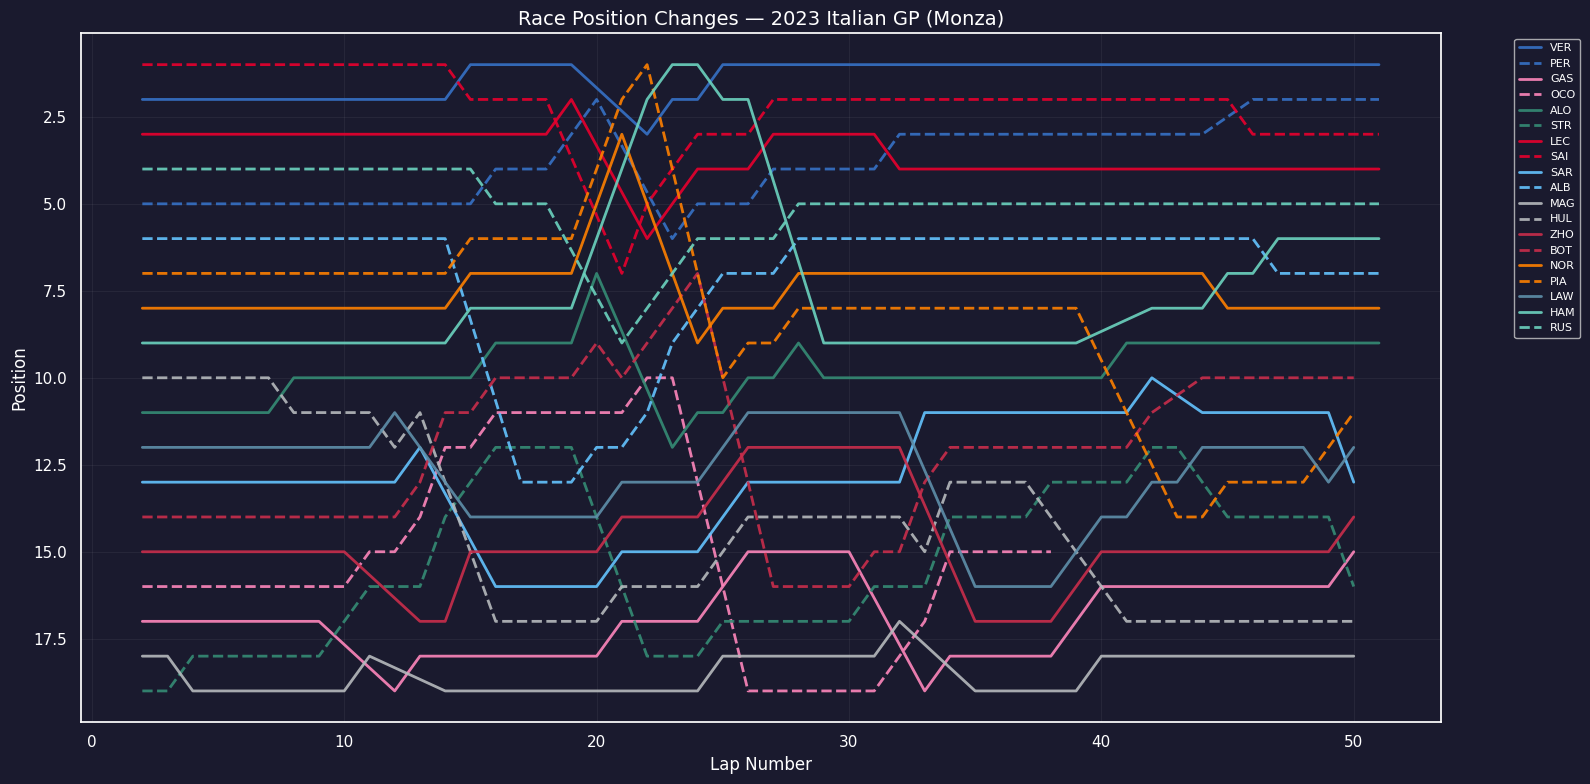

Plot saved


In [6]:
position_data = laps[['Driver', 'LapNumber', 'Position', 'Team']].dropna()

team_colors = get_team_colors()

driver_team = laps[['Driver', 'Team']].drop_duplicates()
driver_color = {
    row['Driver']: team_colors.get(row['Team'], '#FFFFFF')
    for _, row in driver_team.iterrows()
}

team_drivers = {}
for _, row in driver_team.iterrows():
    team_drivers.setdefault(row['Team'], []).append(row['Driver'])

plt.figure(figsize=(16, 8), facecolor='#1a1a2e')
ax = plt.gca()
ax.set_facecolor('#1a1a2e')

for team, drivers in team_drivers.items():
    for i, driver in enumerate(drivers):
        driver_data = position_data[position_data['Driver'] == driver]
        linestyle = '-' if i == 0 else '--'
        ax.plot(driver_data['LapNumber'], driver_data['Position'],
                linewidth=2, label=driver, alpha=0.9,
                color=driver_color[driver],
                linestyle=linestyle)

ax.invert_yaxis()
ax.set_xlabel('Lap Number', color='white')
ax.set_ylabel('Position', color='white')
ax.set_title('Race Position Changes — 2023 Italian GP (Monza)',
             color='white', fontsize=14)
ax.tick_params(colors='white')

# Grid lines — subtle, almost invisible
ax.grid(True, color='white', alpha=0.08, linewidth=0.5)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
          fontsize=8, facecolor='#1a1a2e', labelcolor='white')
plt.tight_layout()

save_path = '/home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/outputs/figures/position_changes.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

## Race Position Changes

Positions were fairly stable for the top 4-5 drivers throughout the race. 
The most interesting movement happened in the midfield during the pit window 
(laps 15-25), where drivers who hadn't pitted yet appeared to be leading — 
Hulkenberg being the clearest example. He sat near P1 for almost 10 laps 
purely due to strategy, before dropping to P17 after his late pit stop.

Tsunoda is absent from this chart entirely — engine failure on the formation 
lap, so he never started the race.

### Note: Yuki Tsunoda (TSU) is absent from this dataset because he suffered an engine failure on the formation lap and never started the race — a DNS (Did Not Start). This is not a data error.

In [30]:
# Find first and last recorded position for each driver
position_changes = []

for driver in laps['Driver'].unique():
    driver_laps = laps[laps['Driver'] == driver].sort_values('LapNumber')
    first_pos = driver_laps.iloc[0]['Position']
    last_pos = driver_laps.iloc[-1]['Position']
    total_laps = driver_laps['LapNumber'].max()
    gained = first_pos - last_pos

    position_changes.append({
        'Driver': driver,
        'StartPosition': first_pos,
        'EndPosition': last_pos,
        'PositionsGained': gained,
        'LapsCompleted': total_laps
    })

pos_df = pd.DataFrame(position_changes).sort_values('PositionsGained', ascending=False)
print(pos_df.to_string(index=False))

Driver  StartPosition  EndPosition  PositionsGained  LapsCompleted
   BOT           14.0         10.0              4.0           50.0
   STR           19.0         16.0              3.0           50.0
   PER            5.0          2.0              3.0           51.0
   HAM            9.0          6.0              3.0           51.0
   GAS           17.0         15.0              2.0           50.0
   ALO           11.0          9.0              2.0           51.0
   VER            2.0          1.0              1.0           51.0
   ZHO           15.0         14.0              1.0           50.0
   OCO           16.0         15.0              1.0           38.0
   MAG           18.0         18.0              0.0           50.0
   SAR           13.0         13.0              0.0           50.0
   LAW           12.0         12.0              0.0           50.0
   NOR            8.0          8.0              0.0           51.0
   LEC            3.0          4.0             -1.0           

## 2. Tyre Compound vs Lap Time
Which tyre compound produced the fastest laps? 
A box plot shows the distribution of lap times for each compound.

Task was destroyed but it is pending!
task: <Task pending name='Task-139' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-140' coro=<Kernel.shell_main() running at /home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/venv/lib/python3.12/site-packages/matplotlib/transforms.py:156: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def invalidate(self):
Task was destroyed but it is pending!
task: <Task pending name='Task-140' coro=<Kernel.shell_main() running at /home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/venv/

Saved: compound_laptimes.png


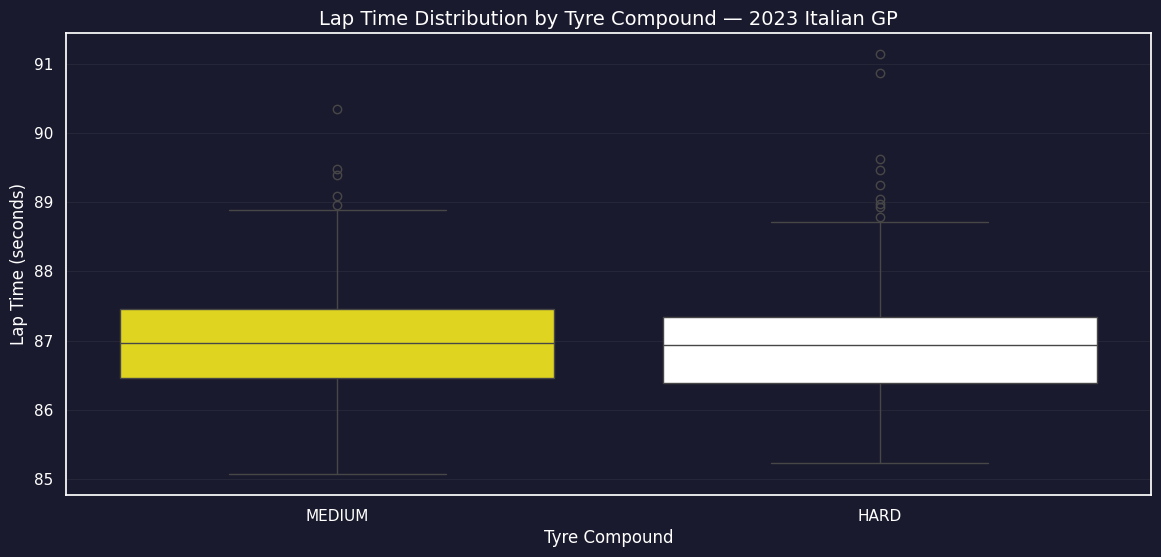

In [31]:
# Filter out outliers — pit laps and safety car laps skew the data
clean = laps[laps['LapTime'] < 120].copy()
compound_colors = get_compound_colors()

fig, ax = setup_dark_plot()
sns.boxplot(data=clean, x='Compound', y='LapTime',
            hue='Compound', palette=compound_colors, ax=ax,
            order=['MEDIUM', 'HARD'], legend=False)
style_dark_labels(ax,
    title='Lap Time Distribution by Tyre Compound — 2023 Italian GP',
    xlabel='Tyre Compound',
    ylabel='Lap Time (seconds)')
save_figure('compound_laptimes.png')
plt.show()

## How tyre compunds affected race pace

Both the Hard and Medium tyre compounds are identical in pace at MOnza.
This makes sense - Monza is a low downforce, high speed circuit. Tyre compunds matter less here than at high-downforce tracks like Monaco.
Hard has more outliers- more variabulity, teams struggled more to keep consistent pace on hard tyres late in stints.

In [13]:
print(clean['Compound'].value_counts())


Compound
HARD      467
MEDIUM    397
Name: count, dtype: int64


## 3. Lap Time Evolution Across the Race
How did lap times change throughout the race? This reveals tyre 
degradation, pit stop laps, and any safety car periods.

Saved: laptime_evolution.png


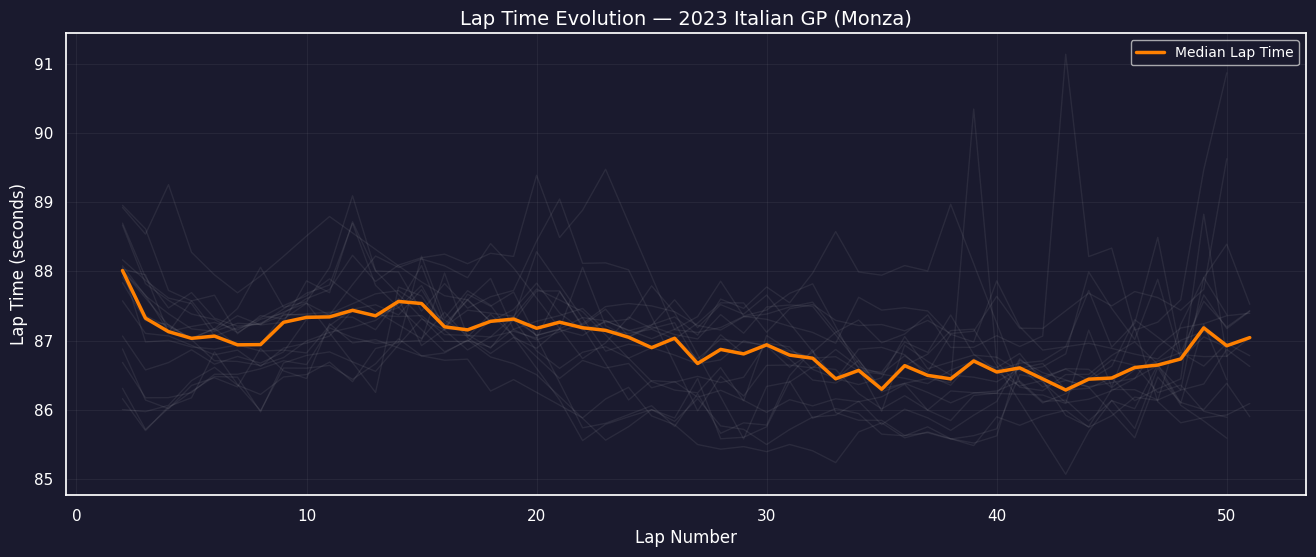

In [32]:
clean = laps[laps['LapTime'] < 120].copy()
avg_laptimes = clean.groupby('LapNumber')['LapTime'].median().reset_index()

fig, ax = setup_dark_plot(figsize=(16, 6))

for driver in clean['Driver'].unique():
    driver_data = clean[clean['Driver'] == driver]
    ax.plot(driver_data['LapNumber'], driver_data['LapTime'],
            color='white', alpha=0.07, linewidth=1)

ax.plot(avg_laptimes['LapNumber'], avg_laptimes['LapTime'],
        color='#FF8000', linewidth=2.5, label='Median Lap Time', zorder=5)

style_dark_labels(ax,
    title='Lap Time Evolution — 2023 Italian GP (Monza)',
    xlabel='Lap Number',
    ylabel='Lap Time (seconds)')
ax.legend(fontsize=10, facecolor='#1a1a2e', labelcolor='white')
save_figure('laptime_evolution.png')
plt.show()

## Lap Time Evolution

I expected lap times to get slower as the race went on — tyres wear out, 
so naturally pace should drop. But the median lap time actually trended 
downward across the race. 

This is because of track evolution — rubber builds up on the racing line 
lap by lap, making the track progressively grippier. At Monza this effect 
is strong enough to offset tyre degradation entirely.

Verstappen's individual lap chart makes this clearest. His times gradually 
improve through his Medium stint, then reset after the pit stop and improve 
again on the Hard tyre — until around lap 45 where the tyres start dying 
and his times spike noticeably in the final laps.

His pit stop laps (20-21) don't appear in the chart at all — FastF1 flagged 
them as inaccurate during cleaning. The gap in the line is where the pit 
stop happened.

Saved: ver_laptime_evolution.png


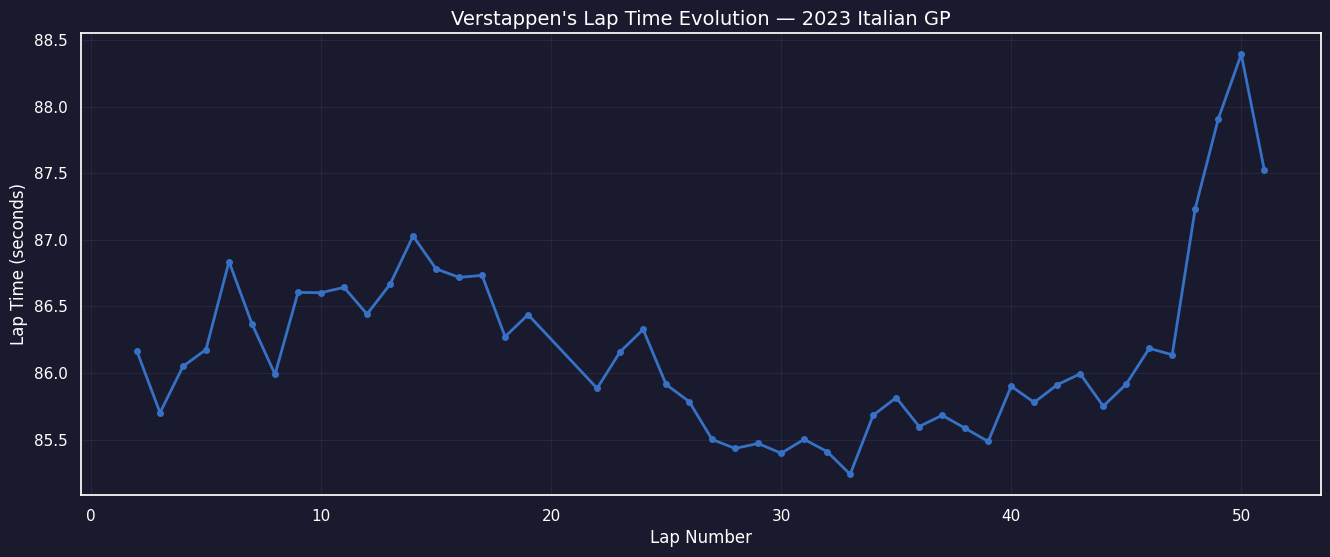

In [33]:
ver = laps[laps['Driver'] == 'VER'].copy()
ver = ver[ver['LapTime'] < 120]

fig, ax = setup_dark_plot(figsize=(16, 6))
ax.plot(ver['LapNumber'], ver['LapTime'],
        color='#3671C6', linewidth=2, marker='o', markersize=4)
style_dark_labels(ax,
    title="Verstappen's Lap Time Evolution — 2023 Italian GP",
    xlabel='Lap Number',
    ylabel='Lap Time (seconds)')
save_figure('ver_laptime_evolution.png')
plt.show()

In [18]:
# Show Verstappen's slowest laps — these are his pit stop laps
ver_all = laps[laps['Driver'] == 'VER'].copy()
print(ver_all.nlargest(3, 'LapTime')[['LapNumber', 'LapTime', 'Compound', 'TyreLife']])

    LapNumber  LapTime Compound  TyreLife
46       50.0   88.393     HARD      30.0
45       49.0   87.907     HARD      29.0
47       51.0   87.525     HARD      31.0


In [19]:
ver_all = laps[laps['Driver'] == 'VER'].copy()
# Show ALL laps including pit stop laps
print(ver_all.nlargest(5, 'LapTime')[['LapNumber', 'LapTime', 'Compound', 'TyreLife']])

    LapNumber  LapTime Compound  TyreLife
46       50.0   88.393     HARD      30.0
45       49.0   87.907     HARD      29.0
47       51.0   87.525     HARD      31.0
44       48.0   87.235     HARD      28.0
12       14.0   87.028   MEDIUM      14.0


In [20]:
ver_all = laps[laps['Driver'] == 'VER'].copy()
print(ver_all[['LapNumber', 'LapTime', 'Compound', 'TyreLife', 'PitInTime']].to_string())

    LapNumber  LapTime Compound  TyreLife  PitInTime
0         2.0   86.163   MEDIUM       2.0        NaN
1         3.0   85.702   MEDIUM       3.0        NaN
2         4.0   86.050   MEDIUM       4.0        NaN
3         5.0   86.176   MEDIUM       5.0        NaN
4         6.0   86.837   MEDIUM       6.0        NaN
5         7.0   86.368   MEDIUM       7.0        NaN
6         8.0   85.990   MEDIUM       8.0        NaN
7         9.0   86.605   MEDIUM       9.0        NaN
8        10.0   86.603   MEDIUM      10.0        NaN
9        11.0   86.643   MEDIUM      11.0        NaN
10       12.0   86.442   MEDIUM      12.0        NaN
11       13.0   86.666   MEDIUM      13.0        NaN
12       14.0   87.028   MEDIUM      14.0        NaN
13       15.0   86.782   MEDIUM      15.0        NaN
14       16.0   86.718   MEDIUM      16.0        NaN
15       17.0   86.733   MEDIUM      17.0        NaN
16       18.0   86.273   MEDIUM      18.0        NaN
17       19.0   86.438   MEDIUM      19.0     

## 4. Team Consistency
Which teams were most consistent throughout the race? 
A lower spread in lap times indicates better consistency.

Saved: team_consistency.png


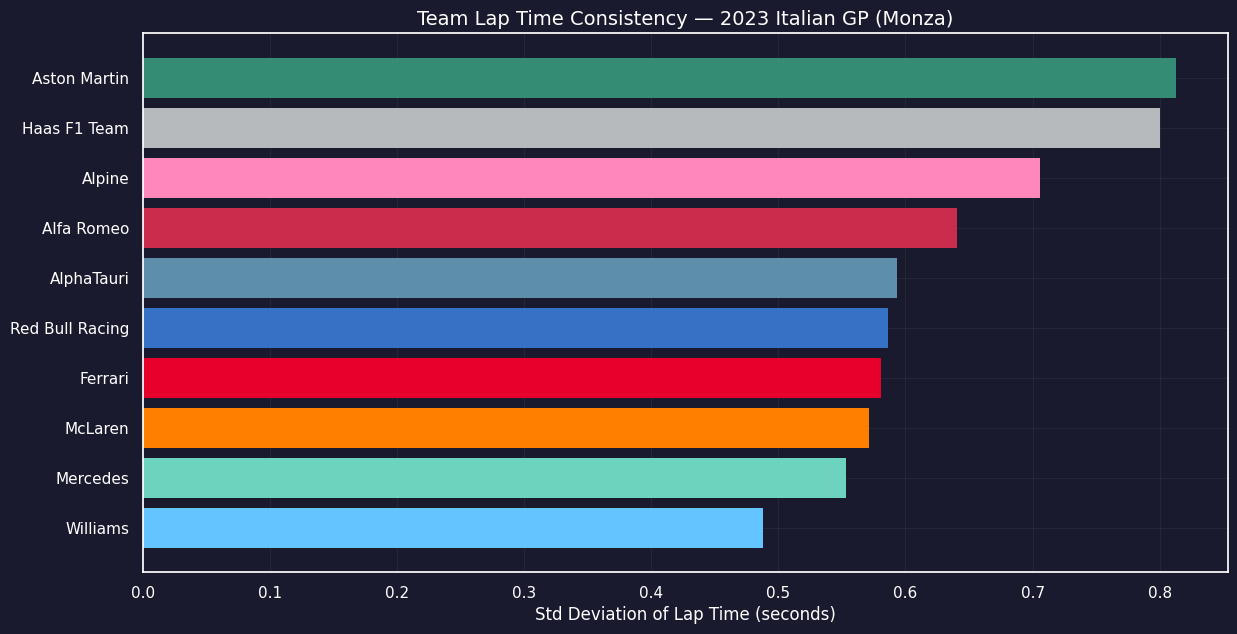

In [34]:
clean = laps[laps['LapTime'] < 120].copy()
team_colors = get_team_colors()
team_consistency = clean.groupby('Team')['LapTime'].std().sort_values()

fig, ax = setup_dark_plot(figsize=(14, 7))
colors = [team_colors.get(team, '#FFFFFF') for team in team_consistency.index]
bars = ax.barh(team_consistency.index, team_consistency.values,
               color=colors, edgecolor='none')
style_dark_labels(ax,
    title='Team Lap Time Consistency — 2023 Italian GP (Monza)',
    xlabel='Std Deviation of Lap Time (seconds)',
    ylabel='')
save_figure('team_consistency.png')
plt.show()

## Team Consistency
Williams was the most consistent throughout but that doesn't always mean they are fast. That makes them predictable. Both the drivers likely ran clean, uneventful races with no strategy changes, no pressure to push.
On the other hand, Aston Martin was the least consistent team but sitll Alonso managed to score points for the team. There was a huge gap between him and his teammate Stroll.